In [9]:
import math
import yaml
import json
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from pathlib import Path
from planner_copy import PlanningEngine


PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd() / "Path_Optimizer"]


def resolve_project_path(path: str) -> Path:
    relative_path = Path(path)
    for root in PROJECT_ROOT_CANDIDATES:
        candidate = root / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{path}' from {Path.cwd()}")


def load_yaml(path: str) -> dict:
    with open(resolve_project_path(path), "r") as f:
        return yaml.safe_load(f)


def load_json(path: str) -> dict:
    with open(resolve_project_path(path), "r") as f:
        return json.load(f)


def initial_state(config: dict) -> np.ndarray:
    state = np.zeros(13, dtype=float)
    state[0:3] = np.asarray(config["X_0"]["p_0"], dtype=np.float64)
    state[3:6] = np.asarray(config["X_0"]["v_0"], dtype=np.float64)
    state[6:10] = np.asarray(config["X_0"]["q_0"], dtype=np.float64)
    state[6:10] /= np.linalg.norm(state[6:10])
    state[10:13] = np.asarray(config["X_0"]["omega_0"], dtype=np.float64)
    return state


def extract_gate_positions(course: dict) -> np.ndarray:
    gates = course["targets"]
    key = "position_cm"
    

    positions: list[list[float]] = []
    for item in gates:
        position = item if key is None else item.get(key) or item.get("position")
        
        positions.append(
            [
                float(position["x"]) * 0.01,
                float(position["y"]) * 0.01,
                float(position["z"]) * 0.01,
            ]
        )

    return np.asarray(positions, dtype=float)


def quaternion_to_rotation_matrix(q: np.ndarray) -> np.ndarray:
    qw, qx, qy, qz = q / np.linalg.norm(q)
    return np.array(
        [
            [1.0 - 2.0 * (qy * qy + qz * qz), 2.0 * (qx * qy - qw * qz), 2.0 * (qx * qz + qw * qy)],
            [2.0 * (qx * qy + qw * qz), 1.0 - 2.0 * (qx * qx + qz * qz), 2.0 * (qy * qz - qw * qx)],
            [2.0 * (qx * qz - qw * qy), 2.0 * (qy * qz + qw * qx), 1.0 - 2.0 * (qx * qx + qy * qy)],
        ],
        dtype=float,
    )

In [10]:
quad_params = load_yaml("../src/quadrotor/params.yaml")
sim_config = load_yaml("../src/sim/config.yaml")
course_path = "../course_model/targets-SimBlank-20260216_194648.json"
course = load_json(course_path)

planner = PlanningEngine(params=quad_params)

state = initial_state(sim_config)
course = extract_gate_positions(course)
gates = course[1:3] if len(course) > 1 else course   # exclude origin

initial_guess = planner.generate_initial_guess(gates, x0=state, nodes_per_segment=20)

# optimized_path = planner.optimize_cpc(guess=initial_guess, gates_rel=gates[:3], x_current=state, d_tol=1.2, max_iter=800)

optimized_path = planner.optimize_cpc(
    initial_guess, 
    gates, 
    x_current=state, 
    d_tol=2.0,          # you can now try tighter values like 0.8-1.0
    max_iter=400
)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     7377
Number of nonzeros in inequality constraint Jacobian.:     1543
Number of nonzeros in Lagrangian Hessian.............:     5210

Total number of variables............................:      936
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      617
Total number of inequality constraints...............:      929
        inequality constraints with only lower bounds:      485
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:      444

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.0489336e+00 1.68e+01 1.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

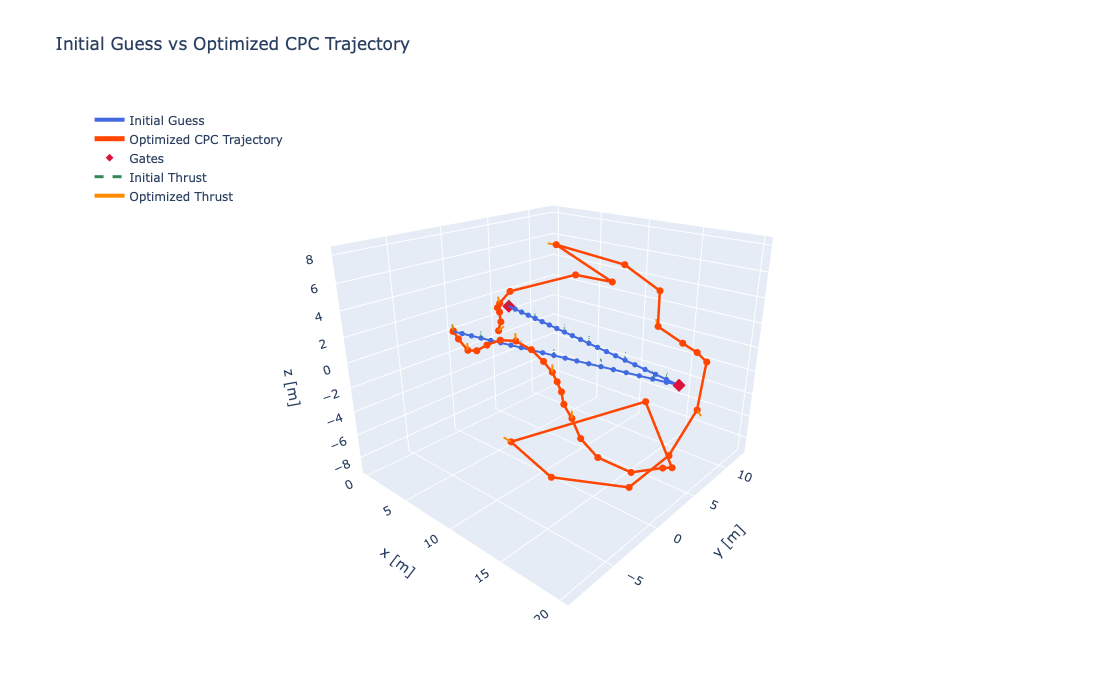

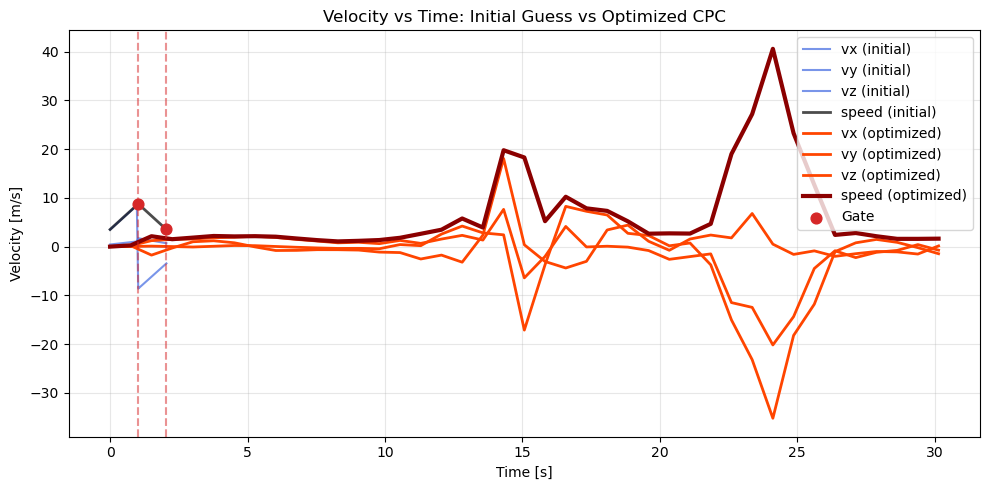

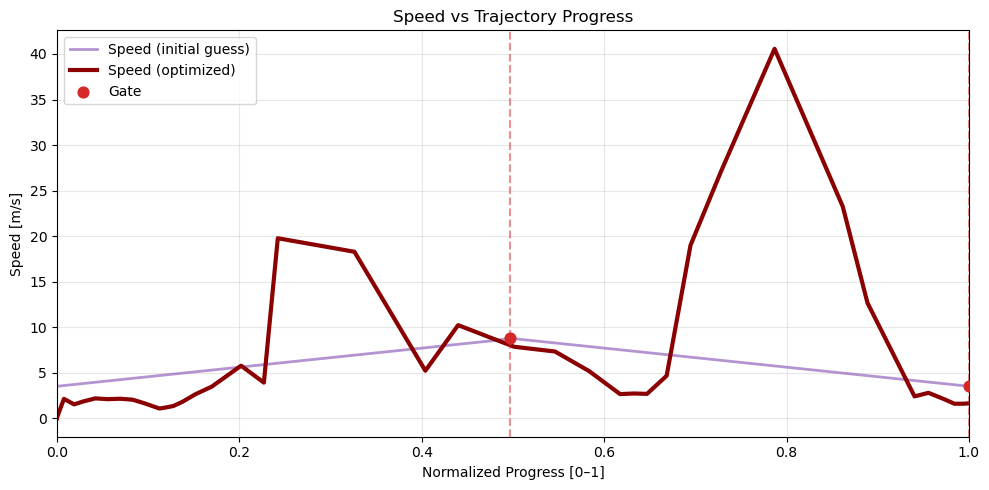

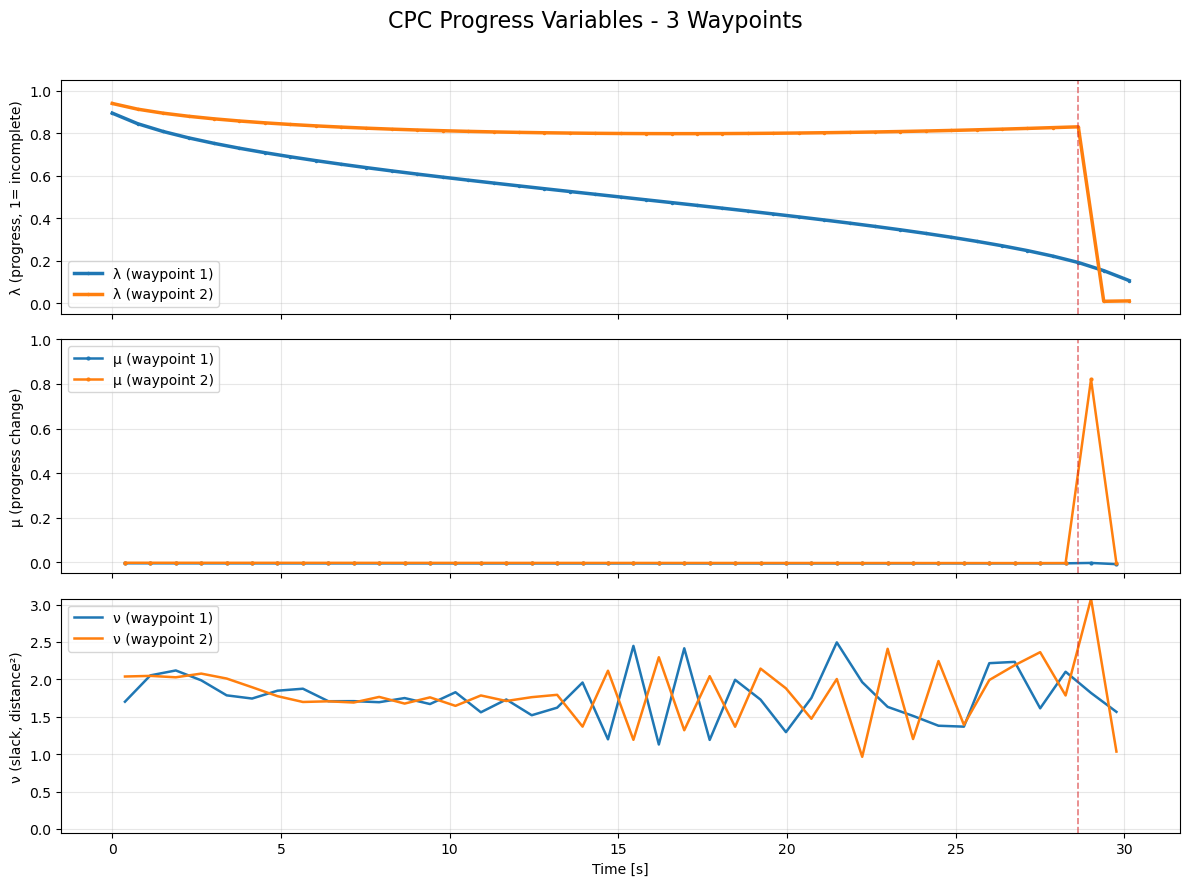

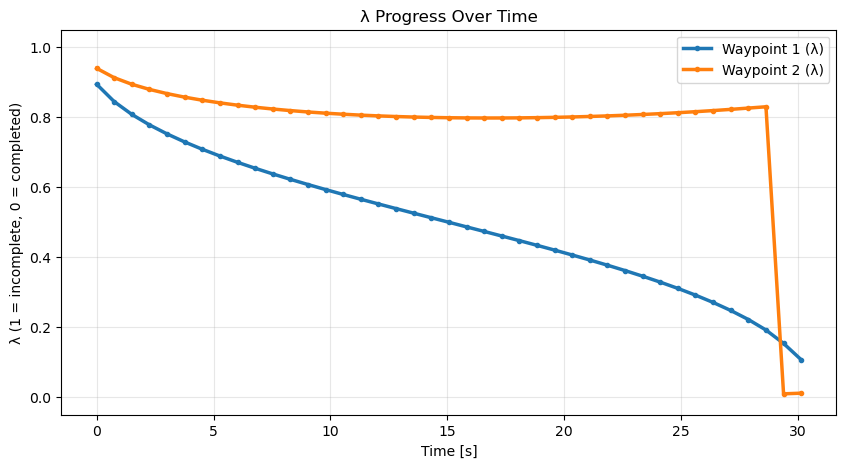

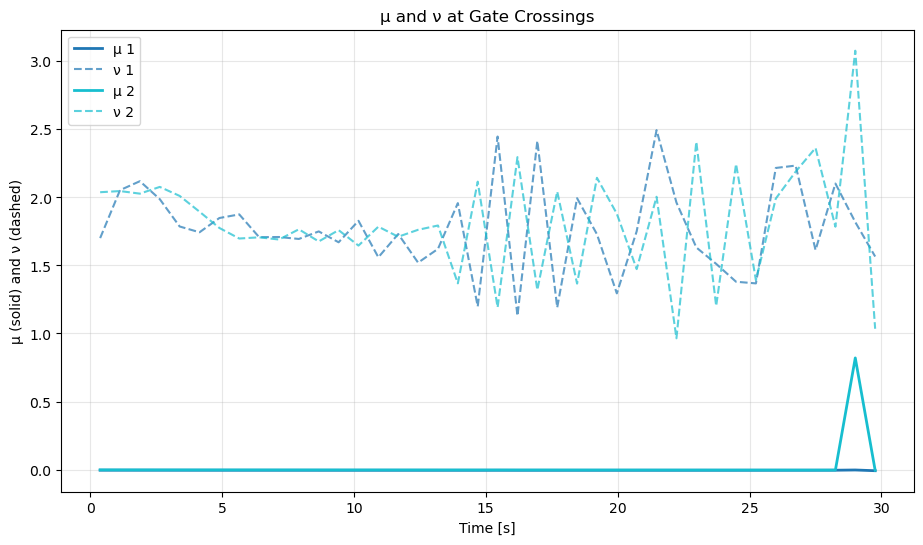

In [12]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# ====================== 3D Trajectory with Thrust Vectors ======================
def plot_3d_trajectories(initial_guess, optimized_path, gates, title="Trajectory Comparison"):
    # Initial guess (reference)
    traj_ref = np.asarray(initial_guess["x"], dtype=float)
    pos_ref = traj_ref[:, 0:3]
    quat_ref = traj_ref[:, 6:10]

    # Optimized
    traj_opt = np.asarray(optimized_path["x"], dtype=float)
    pos_opt = traj_opt[:, 0:3]
    quat_opt = traj_opt[:, 6:10]

    # Thrust direction in body frame (positive thrust is -Z_body in our convention, but we plot +Z for visibility)
    thrust_body = np.array([0.0, 0.0, 1.0], dtype=float)

    def get_thrust_directions(quaternions):
        return np.array([quaternion_to_rotation_matrix(q) @ thrust_body for q in quaternions])

    thrust_dir_ref = get_thrust_directions(quat_ref)
    thrust_dir_opt = get_thrust_directions(quat_opt)

    # Sampling for vectors (limit number for clarity)
    num_vectors = min(12, len(pos_ref))
    vector_indices = np.unique(np.linspace(0, len(pos_ref) - 1, num_vectors, dtype=int))

    span = np.ptp(np.vstack([pos_ref, pos_opt]), axis=0)
    vector_scale = max(float(np.max(span)) * 0.03, 0.08)

    fig = go.Figure()

    # Reference trajectory (blue)
    fig.add_trace(
        go.Scatter3d(
            x=pos_ref[:, 0], y=pos_ref[:, 1], z=pos_ref[:, 2],
            mode="lines+markers",
            name="Initial Guess",
            line=dict(color="royalblue", width=4),
            marker=dict(size=3),
        )
    )

    # Optimized trajectory (orange/red)
    fig.add_trace(
        go.Scatter3d(
            x=pos_opt[:, 0], y=pos_opt[:, 1], z=pos_opt[:, 2],
            mode="lines+markers",
            name="Optimized CPC Trajectory",
            line=dict(color="orangered", width=5),
            marker=dict(size=4),
        )
    )

    # Gates
    fig.add_trace(
        go.Scatter3d(
            x=gates[:3, 0], y=gates[:3, 1], z=gates[:3, 2],   # show first few gates
            mode="markers",
            name="Gates",
            marker=dict(size=6, color="crimson", symbol="diamond"),
        )
    )

    # Thrust directions - Reference (seagreen)
    for i, idx in enumerate(vector_indices):
        start = pos_ref[idx]
        end = start + vector_scale * thrust_dir_ref[idx]
        fig.add_trace(
            go.Scatter3d(
                x=[start[0], end[0]],
                y=[start[1], end[1]],
                z=[start[2], end[2]],
                mode="lines",
                name="Initial Thrust" if i == 0 else None,
                showlegend=(i == 0),
                line=dict(color="seagreen", width=3, dash="dash"),
            )
        )

    # Thrust directions - Optimized (darkorange)
    for i, idx in enumerate(vector_indices):
        start = pos_opt[idx]
        end = start + vector_scale * thrust_dir_opt[idx]
        fig.add_trace(
            go.Scatter3d(
                x=[start[0], end[0]],
                y=[start[1], end[1]],
                z=[start[2], end[2]],
                mode="lines",
                name="Optimized Thrust" if i == 0 else None,
                showlegend=(i == 0),
                line=dict(color="darkorange", width=4),
            )
        )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x [m]",
            yaxis_title="y [m]",
            zaxis_title="z [m]",
            aspectmode="data",
            camera=dict(eye=dict(x=1.4, y=-1.6, z=0.9)),
        ),
        width=950,
        height=700,
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    )

    fig.show()


# ====================== Velocity vs Time ======================
def plot_velocity_time(initial_guess, optimized_path, gates):
    # Reference
    t_ref = np.asarray(initial_guess["t"], dtype=float)
    states_ref = np.asarray(initial_guess["x"], dtype=float)
    vel_ref = states_ref[:, 3:6]
    speed_ref = np.linalg.norm(vel_ref, axis=1)

    # Optimized
    t_opt = np.asarray(optimized_path["t"], dtype=float)
    states_opt = np.asarray(optimized_path["x"], dtype=float)
    vel_opt = states_opt[:, 3:6]
    speed_opt = np.linalg.norm(vel_opt, axis=1)

    gate_positions = gates[:2]
    # Find closest points on reference for gate lines (for visual consistency)
    gate_indices_ref = [np.argmin(np.linalg.norm(states_ref[:, 0:3] - g, axis=1)) for g in gate_positions]

    fig, ax = plt.subplots(figsize=(10, 5))

    # Reference
    ax.plot(t_ref, vel_ref[:, 0], label="vx (initial)", color="royalblue", alpha=0.7)
    ax.plot(t_ref, vel_ref[:, 1], label="vy (initial)", color="royalblue", alpha=0.7)
    ax.plot(t_ref, vel_ref[:, 2], label="vz (initial)", color="royalblue", alpha=0.7)
    ax.plot(t_ref, speed_ref, label="speed (initial)", color="black", linewidth=2, alpha=0.7)

    # Optimized
    ax.plot(t_opt, vel_opt[:, 0], label="vx (optimized)", color="orangered", linewidth=2)
    ax.plot(t_opt, vel_opt[:, 1], label="vy (optimized)", color="orangered", linewidth=2)
    ax.plot(t_opt, vel_opt[:, 2], label="vz (optimized)", color="orangered", linewidth=2)
    ax.plot(t_opt, speed_opt, label="speed (optimized)", color="darkred", linewidth=3)

    # Gate markers on reference
    for i, g_idx in enumerate(gate_indices_ref):
        gate_time = t_ref[g_idx]
        gate_speed = speed_ref[g_idx]
        ax.axvline(gate_time, color="tab:red", linestyle="--", alpha=0.5)
        ax.scatter(gate_time, gate_speed, color="tab:red", s=60, zorder=5,
                   label="Gate" if i == 0 else None)

    ax.set_title("Velocity vs Time: Initial Guess vs Optimized CPC")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Velocity [m/s]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# ====================== Speed vs Progress ======================
def plot_speed_progress(initial_guess, optimized_path, gates):
    # Reference
    states_ref = np.asarray(initial_guess["x"], dtype=float)
    pos_ref = states_ref[:, 0:3]
    vel_ref = states_ref[:, 3:6]
    speed_ref = np.linalg.norm(vel_ref, axis=1)

    segment_lengths_ref = np.linalg.norm(np.diff(pos_ref, axis=0), axis=1)
    cum_dist_ref = np.concatenate(([0.0], np.cumsum(segment_lengths_ref)))
    progress_ref = cum_dist_ref / cum_dist_ref[-1] if cum_dist_ref[-1] > 0 else cum_dist_ref

    # Optimized
    states_opt = np.asarray(optimized_path["x"], dtype=float)
    pos_opt = states_opt[:, 0:3]
    vel_opt = states_opt[:, 3:6]
    speed_opt = np.linalg.norm(vel_opt, axis=1)

    segment_lengths_opt = np.linalg.norm(np.diff(pos_opt, axis=0), axis=1)
    cum_dist_opt = np.concatenate(([0.0], np.cumsum(segment_lengths_opt)))
    progress_opt = cum_dist_opt / cum_dist_opt[-1] if cum_dist_opt[-1] > 0 else cum_dist_opt

    gate_positions = gates[:2]
    gate_indices_ref = [np.argmin(np.linalg.norm(pos_ref - g, axis=1)) for g in gate_positions]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(progress_ref, speed_ref, label="Speed (initial guess)", color="tab:purple", linewidth=2, alpha=0.7)
    ax.plot(progress_opt, speed_opt, label="Speed (optimized)", color="darkred", linewidth=3)

    for i, g_idx in enumerate(gate_indices_ref):
        gate_prog = progress_ref[g_idx]
        gate_speed = speed_ref[g_idx]
        ax.axvline(gate_prog, color="tab:red", linestyle="--", alpha=0.5)
        ax.scatter(gate_prog, gate_speed, color="tab:red", s=60, zorder=5,
                   label="Gate" if i == 0 else None)

    ax.set_title("Speed vs Trajectory Progress")
    ax.set_xlabel("Normalized Progress [0–1]")
    ax.set_ylabel("Speed [m/s]")
    ax.set_xlim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_progress_variables(optimized: dict, gates: np.ndarray, title: str = "CPC Progress Variables"):
    """
    Plot λ (progress), μ (progress change), and ν (slack) for all waypoints.
    
    optimized: output dict from optimize_cpc() containing 't', 'lam', 'mu', 'nu'
    gates:     full gate array (including origin if you stored it)
    """
    t = np.asarray(optimized['t'])
    lam = np.asarray(optimized['lam'])   # shape (N_nodes, M)
    mu  = np.asarray(optimized['mu'])    # shape (N, M)
    nu  = np.asarray(optimized['nu'])    # shape (N, M)
    
    N_nodes = lam.shape[0]
    M = lam.shape[1]                     # number of future waypoints
    t_mu = t[:-1] + (t[1] - t[0])/2      # center mu/nu on intervals

    fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(title, fontsize=16)

    # 1. λ (progress) - should step from 1 → 0 at each gate
    for j in range(M):
        axs[0].plot(t, lam[:, j], label=f'λ (waypoint {j+1})', linewidth=2.5, marker='.', markersize=3)
    axs[0].set_ylabel('λ (progress, 1= incomplete)')
    axs[0].set_ylim(-0.05, 1.05)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # 2. μ (progress change) - spikes only when passing a gate
    for j in range(M):
        axs[1].plot(t_mu, mu[:, j], label=f'μ (waypoint {j+1})', linewidth=1.8, marker='o', markersize=2)
    axs[1].set_ylabel('μ (progress change)')
    axs[1].set_ylim(-0.05, max(1.0, mu.max()*1.1))
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    # 3. ν (slack distance²) - should be near 0 when μ is active
    for j in range(M):
        axs[2].plot(t_mu, nu[:, j], label=f'ν (waypoint {j+1})', linewidth=1.8)
    axs[2].set_ylabel('ν (slack, distance²)')
    axs[2].set_xlabel('Time [s]')
    axs[2].set_ylim(-0.05, (nu.max() if nu.max() > 0 else 1.0))
    axs[2].grid(True, alpha=0.3)
    axs[2].legend()

    # Add vertical lines at approximate gate crossing times (optional visual aid)
    # You can improve this by finding actual min-distance times if desired
    for j in range(M):
        # rough estimate from λ drop
        idx = np.where(np.diff(lam[:, j]) < -0.1)[0]
        if len(idx) > 0:
            gate_time = t[idx[0]]
            for ax in axs:
                ax.axvline(gate_time, color='tab:red', linestyle='--', alpha=0.6, linewidth=1.2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_lambda_only(optimized: dict, title: str = "λ Progress Over Time"):
    """Simple single plot showing only the λ curves (easiest to check ordering)."""
    t = np.asarray(optimized['t'])
    lam = np.asarray(optimized['lam'])
    M = lam.shape[1]

    plt.figure(figsize=(10, 5))
    for j in range(M):
        plt.plot(t, lam[:, j], label=f'Waypoint {j+1} (λ)', linewidth=2.5, marker='.')
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel('λ (1 = incomplete, 0 = completed)')
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_mu_nu_combined(optimized: dict, title: str = "μ and ν at Gate Crossings"):
    """Combined plot of μ (spikes) and ν (slack) to verify complementarity."""
    t = np.asarray(optimized['t'])
    mu = np.asarray(optimized['mu'])
    nu = np.asarray(optimized['nu'])
    t_mu = t[:-1] + (t[1]-t[0])/2
    M = mu.shape[1]

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, M))

    for j in range(M):
        ax.plot(t_mu, mu[:, j], label=f'μ {j+1}', color=colors[j], linewidth=2)
        ax.plot(t_mu, nu[:, j], label=f'ν {j+1}', color=colors[j], linestyle='--', alpha=0.7)

    ax.set_xlabel('Time [s]')
    ax.set_ylabel('μ (solid) and ν (dashed)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# ====================== Call the plots ======================

# Assuming you have these variables already:
# initial_guess, optimized_path, gates, and quaternion_to_rotation_matrix function

plot_3d_trajectories(initial_guess, optimized_path, gates,
                     title="Initial Guess vs Optimized CPC Trajectory")

plot_velocity_time(initial_guess, optimized_path, gates)

plot_speed_progress(initial_guess, optimized_path, gates)

# Full progress plot (recommended first)
plot_progress_variables(optimized_path, gates, 
                        title="CPC Progress Variables - 3 Waypoints")

# Quick check of λ ordering
plot_lambda_only(optimized_path)

# Check complementarity behavior
plot_mu_nu_combined(optimized_path)

In [24]:
drone_sates = initial_guess["x"]

for n, gate in enumerate(gates):
    print(f"Gate {n+1}")
    gate_x = gate[0]
    gate_y = gate[1]
    gate_z = gate[2]
    
    ds = []
    
    for state in drone_sates:
        drone_x = state[0]
        drone_y = state[1]
        drone_z = state[2]

        d = math.sqrt((drone_x - gate_x)**2 + (drone_y - gate_y)**2 + (drone_z - gate_z)**2)

        ds.append(d)

    print(min(ds))

Gate 1
0.0
Gate 2
0.11872275997548538
Gate 3
0.0
